In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import random

from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, AveragePooling2D,
    Dense, Dropout, Flatten,
    Input, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

tf.keras.backend.clear_session()

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.19.0


In [ ]:
(ds_train, ds_val), ds_info = tfds.load(
    "imagenette/160px",
    split=["train", "validation"],
    as_supervised=True,
    with_info=True
)

NUM_CLASSES = ds_info.features["label"].num_classes
print("Number of classes:", NUM_CLASSES)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imagenette/160px/incomplete.HBRPOI_1.0.0/imagenette-train.tfrecord*...:   …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imagenette/160px/incomplete.HBRPOI_1.0.0/imagenette-validation.tfrecord*..…

Dataset imagenette downloaded and prepared to /root/tensorflow_datasets/imagenette/160px/1.0.0. Subsequent calls will reuse this data.
Number of classes: 10


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

train_ds = ds_train.map(preprocess)\
                   .shuffle(1000)\
                   .batch(BATCH_SIZE)\
                   .prefetch(tf.data.AUTOTUNE)

val_ds = ds_val.map(preprocess)\
               .batch(BATCH_SIZE)\
               .prefetch(tf.data.AUTOTUNE)


In [ ]:
def inception_module(x,
                     f1,
                     f3_reduce, f3,
                     f5_reduce, f5,
                     f_pool):

    # 1x1 branch
    branch1 = Conv2D(f1, (1,1), padding='same', activation='relu')(x)

    # 1x1 -> 3x3 branch
    branch2 = Conv2D(f3_reduce, (1,1), padding='same', activation='relu')(x)
    branch2 = Conv2D(f3, (3,3), padding='same', activation='relu')(branch2)

    # 1x1 -> 5x5 branch
    branch3 = Conv2D(f5_reduce, (1,1), padding='same', activation='relu')(x)
    branch3 = Conv2D(f5, (5,5), padding='same', activation='relu')(branch3)

    # Pooling branch
    branch4 = MaxPooling2D((3,3), strides=1, padding='same')(x)
    branch4 = Conv2D(f_pool, (1,1), padding='same', activation='relu')(branch4)

    # Concatenate
    output = Concatenate()([branch1, branch2, branch3, branch4])

    return output


In [ ]:
def build_googlenet(input_shape=(224,224,3), num_classes=10):

    inputs = Input(shape=input_shape)

    # Initial layers
    x = Conv2D(64, (7,7), strides=2, padding='same', activation='relu')(inputs)
    x = MaxPooling2D((3,3), strides=2, padding='same')(x)

    x = Conv2D(64, (1,1), activation='relu', padding='same')(x)
    x = Conv2D(192, (3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D((3,3), strides=2, padding='same')(x)

    # Inception blocks
    x = inception_module(x, 64, 96, 128, 16, 32, 32)
    x = inception_module(x, 128, 128, 192, 32, 96, 64)
    x = MaxPooling2D((3,3), strides=2, padding='same')(x)

    x = inception_module(x, 192, 96, 208, 16, 48, 64)
    x = inception_module(x, 160, 112, 224, 24, 64, 64)
    x = inception_module(x, 128, 128, 256, 24, 64, 64)
    x = inception_module(x, 112, 144, 288, 32, 64, 64)
    x = inception_module(x, 256, 160, 320, 32, 128, 128)
    x = MaxPooling2D((3,3), strides=2, padding='same')(x)

    x = inception_module(x, 256, 160, 320, 32, 128, 128)
    x = inception_module(x, 384, 192, 384, 48, 128, 128)

    # Global Average Pooling (GoogLeNet key idea)
    x = AveragePooling2D((7,7))(x)
    x = Flatten()(x)
    x = Dropout(0.4)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name="GoogLeNet")

    return model


In [ ]:
googlenet = build_googlenet()

googlenet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

googlenet.summary()


Model: "GoogLeNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │      4,160 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │    110,784 │ conv2d_1[0][0]    │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 28, 28,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28,    │     18,528 │ max_pooling2d_1[… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 28, 28,    │      3,088 │ max_pooling2d_1[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ max_pooling2d_1[… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │     12,352 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 28, 28,    │    110,720 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 28, 28,    │     12,832 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 28, 28,    │      6,176 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 28, 28,    │          0 │ conv2d_3[0][0],   │
│ (Concatenate)       │ 256)              │            │ conv2d_5[0][0],   │
│                     │                   │            │ conv2d_7[0][0],   │
│                     │                   │            │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 28, 28,    │     32,896 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 28, 28,    │      8,224 │ concatenate[0][0] │
│                     │ 32)               │            │                 

 Total params: 5,983,802 (22.83 MB)

 Trainable params: 5,983,802 (22.83 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 5

history = googlenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 128s 217ms/step - accuracy: 0.1522 - loss: 2.2278 - val_accuracy: 0.3020 - val_loss: 1.9494
Epoch 2/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 53s 129ms/step - accuracy: 0.3159 - loss: 1.8965 - val_accuracy: 0.4320 - val_loss: 1.5970
Epoch 3/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 53s 131ms/step - accuracy: 0.4108 - loss: 1.6670 - val_accuracy: 0.4660 - val_loss: 1.4695
Epoch 4/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 53s 131ms/step - accuracy: 0.4985 - loss: 1.4662 - val_accuracy: 0.5160 - val_loss: 1.4113
Epoch 5/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 53s 131ms/step - accuracy: 0.5625 - loss: 1.2991 - val_accuracy: 0.6280 - val_loss: 1.1186


In [ ]:
loss, acc = googlenet.evaluate(val_ds)

print("\n===== GOOGLENET PERFORMANCE =====")
print(f"Validation Accuracy : {acc * 100:.2f}%")
print(f"Validation Loss     : {loss:.4f}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6459 - loss: 1.1081

===== GOOGLENET PERFORMANCE =====
Validation Accuracy : 62.80%
Validation Loss     : 1.1186


In [ ]:
print("\n===== MODEL DETAILS =====")
print("Total Parameters :", f"{googlenet.count_params():,}")
print("Total Layers     :", len(googlenet.layers))



===== MODEL DETAILS =====
Total Parameters : 5,983,802
Total Layers     : 84


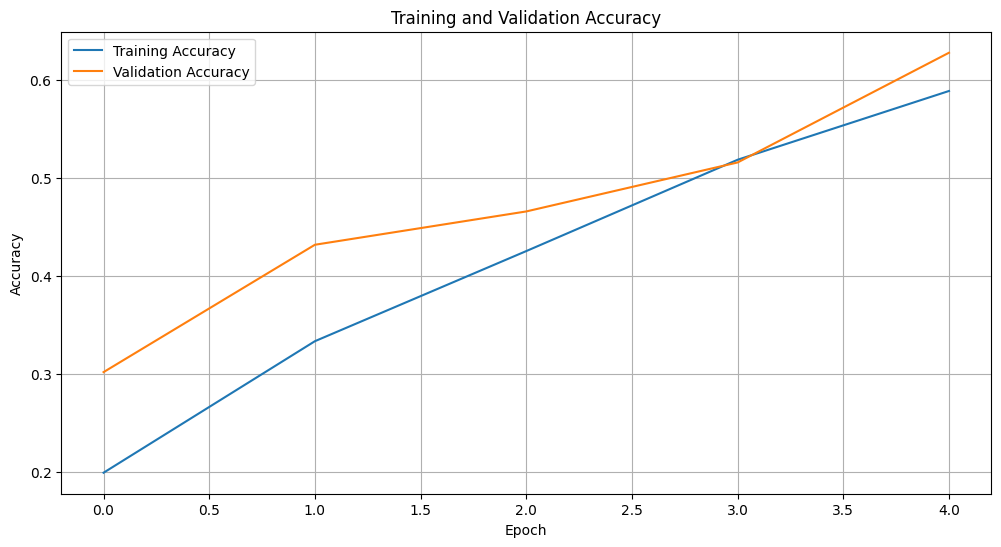

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

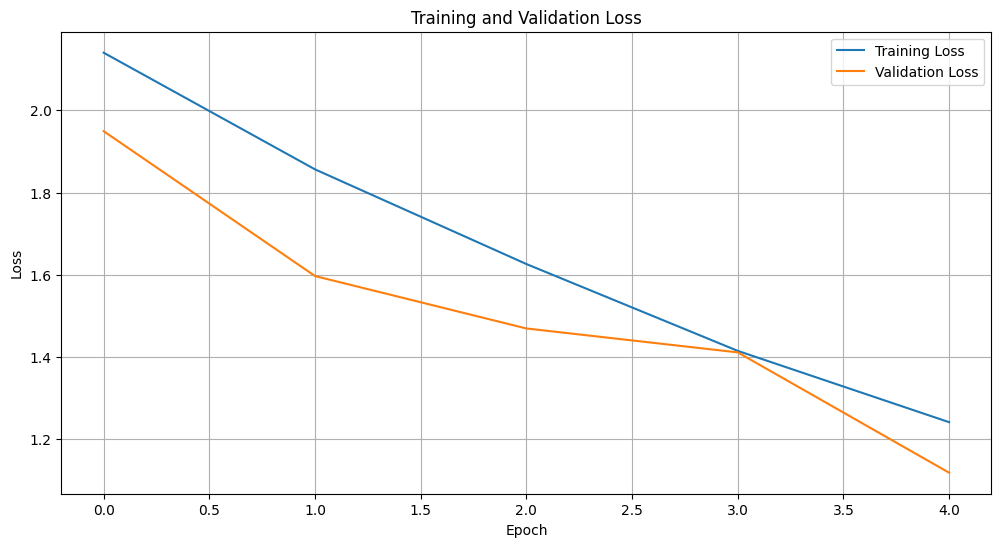

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()